
# Healthcare Risk Prediction — 30-Day Readmission (UCI Diabetes Dataset)

This notebook builds a clear, reproducible pipeline to predict **30-day hospital readmission** using the UCI Diabetes dataset you provided.

**You'll see:**
1) Load & preview data (+ ID mapping)  
2) Clean and preprocess (handle `'?'`, encode categories, scale numerics)  
3) Feature engineering (simplify diagnosis codes, create counts)  
4) Define target (`readmitted` → 1 if `<30`, else 0)  
5) Train/test split  
6) Baseline model (Logistic Regression) + Tree model (Random Forest)  
7) Evaluate with ROC AUC, PR AUC, Precision, Recall, F1, Confusion Matrix  
8) Friendly, business-focused summary


In [1]:

# 1) Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
                             confusion_matrix, accuracy_score, precision_score, recall_score, f1_score)

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (6,4)


In [3]:

# 2) Load data & ID mappings
data_path = "diabetic_data.csv"       # uploaded dataset
map_path  = "IDS_mapping.csv"         # uploaded ID mapping

df = pd.read_csv(data_path)
print("Raw shape:", df.shape)
display(df.head(10))

# Try to load ID mapping (optional)
try:
    ids_map = pd.read_csv(map_path)
    print("\nID mapping file loaded:", ids_map.shape, "rows")
    display(ids_map.head())
except Exception as e:
    ids_map = None
    print("\nID mapping file not used:", e)

print("\nColumns:", list(df.columns))
print("\nMissing marker counts ('?') per column:")
print((df == '?').sum())


Raw shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,?,?,31,6,16,0,0,0,414,411,250,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,?,?,70,1,21,0,0,0,414,411,V45,7,NaN,NaN,Steady,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,?,?,73,0,12,0,0,0,428,492,250,8,NaN,NaN,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,?,?,68,2,28,0,0,0,398,427,38,8,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,?,InternalMedicine,33,3,18,0,0,0,434,198,486,8,NaN,NaN,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO



ID mapping file loaded: (67, 2) rows


,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available



Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Missing marker counts ('?') per column:
encounter_id                    0
patient_nbr                     0
race                         2273
gender                       

In [4]:

# 3) Basic cleaning
# Replace '?' with NaN
df = df.replace('?', np.nan)

# Drop purely ID / leakage columns
drop_cols = [c for c in ["encounter_id", "patient_nbr"] if c in df.columns]

# Columns with extreme missingness or low value for modeling (commonly dropped in this dataset)
for c in ["weight", "payer_code"]:
    if c in df.columns:
        drop_cols.append(c)

df = df.drop(columns=drop_cols, errors="ignore")

# Convert readmitted to binary target: 1 if <30, else 0
if "readmitted" in df.columns:
    df["readmit_30d"] = (df["readmitted"] == "<30").astype(int)
    df = df.drop(columns=["readmitted"], errors="ignore")
else:
    raise ValueError("Expected column 'readmitted' not found.")

print("After cleaning, shape:", df.shape)
display(df.head(5))


After cleaning, shape: (101766, 46)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmit_30d
0,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,[10-20),1,1,7,3,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),1,1,7,2,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),1,1,7,1,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,0


In [5]:

# 4) Feature engineering helpers
# Simplify ICD9 codes (diag_1/2/3) into broad groups per common practice
def icd9_group(code):
    # code may be string, numeric-like, or NaN
    try:
        if pd.isna(code): 
            return "missing"
        # Handle V and E codes (non-numeric)
        if isinstance(code, str) and (code.startswith('V') or code.startswith('E')):
            return "supplemental"
        val = float(code)
    except Exception:
        return "other"
    # Map ranges (simple, high-level group)
    if 390 <= val <= 459 or val == 785:
        return "circulatory"
    if 460 <= val <= 519 or val == 786:
        return "respiratory"
    if 520 <= val <= 579 or val == 787:
        return "digestive"
    if 250 <= val < 251:
        return "diabetes"
    if 800 <= val <= 999:
        return "injury"
    if 710 <= val <= 739:
        return "musculoskeletal"
    if 580 <= val <= 629 or val == 788:
        return "genitourinary"
    if 140 <= val <= 239:
        return "neoplasms"
    return "other"

diag_cols = [c for c in ["diag_1","diag_2","diag_3"] if c in df.columns]
for c in diag_cols:
    df[c+"_group"] = df[c].apply(icd9_group)

# Create count of diagnoses present
df["num_diagnoses"] = df[[c for c in diag_cols if c in df.columns]].notna().sum(axis=1)

# Example binary flags from medications change
if "change" in df.columns:
    df["meds_changed"] = (df["change"] == "Ch").astype(int)

# Drop original raw diag columns to reduce high-cardinality
df = df.drop(columns=diag_cols, errors="ignore")

print("After feature engineering, shape:", df.shape)
display(df.head(5))


After feature engineering, shape: (101766, 48)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmit_30d,diag_1_group,diag_2_group,diag_3_group,num_diagnoses,meds_changed
0,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,41,0,1,0,0,0,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,diabetes,missing,missing,1,0
1,Caucasian,Female,[10-20),1,1,7,3,NaN,59,0,18,0,0,0,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0,other,diabetes,other,3,1
2,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,11,5,13,2,0,1,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,0,other,diabetes,supplemental,3,0
3,Caucasian,Male,[30-40),1,1,7,2,NaN,44,1,16,0,0,0,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0,other,diabetes,circulatory,3,1
4,Caucasian,Male,[40-50),1,1,7,1,NaN,51,0,8,0,0,0,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,0,neoplasms,neoplasms,diabetes,3,1


In [6]:

# 5) Choose features: separate numeric and categorical
target = "readmit_30d"

# Identify numeric columns (keep common clinical numerics if present)
num_candidates = ["time_in_hospital","num_lab_procedures","num_procedures","num_medications",
                  "number_outpatient","number_emergency","number_inpatient","number_diagnoses",
                  "num_diagnoses"]
numeric_cols = [c for c in num_candidates if c in df.columns]

# Everything else (excluding target) treat as categorical
exclude_cols = set([target] + numeric_cols)
categorical_cols = [c for c in df.columns if c not in exclude_cols]

print("Numeric columns:", numeric_cols)
print("Categorical columns (sample):", categorical_cols[:10])


Numeric columns: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'num_diagnoses']
Categorical columns (sample): ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty', 'max_glu_serum', 'A1Cresult', 'metformin']


In [7]:

# 6) Train/test split
X = df.drop(columns=[target])
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Readmit rate (overall):", y.mean().round(4))


Train shape: (81412, 47)  Test shape: (20354, 47)
Readmit rate (overall): 0.1116


In [8]:

# 7) Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, [c for c in X.columns if c in numeric_cols]),
        ("cat", categorical_transformer, [c for c in X.columns if c in categorical_cols])
    ],
    remainder="drop"
)

print("Preprocessing ready.")


Preprocessing ready.


In [9]:

# 8) Train models
logreg = Pipeline(steps=[("preprocess", preprocess),
                         ("model", LogisticRegression(max_iter=500))])

rf = Pipeline(steps=[("preprocess", preprocess),
                     ("model", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))])

logreg.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("Models trained: Logistic Regression & Random Forest")


Models trained: Logistic Regression & Random Forest



=== Logistic Regression ===
ROC AUC: 0.6812
PR AUC (Avg Precision): 0.2258
Accuracy: 0.8882
Precision: 0.4675
Recall: 0.0159
F1-score: 0.0307
Confusion Matrix (TN, FP; FN, TP):
 [[18042    41]
 [ 2235    36]]


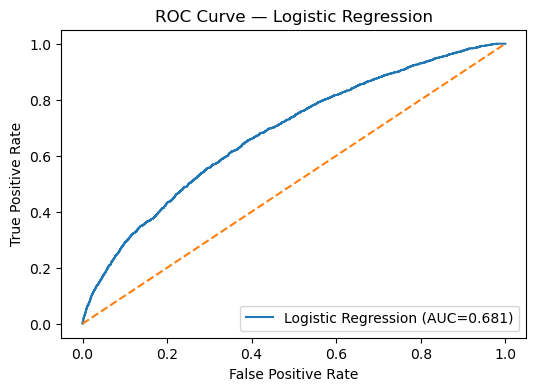

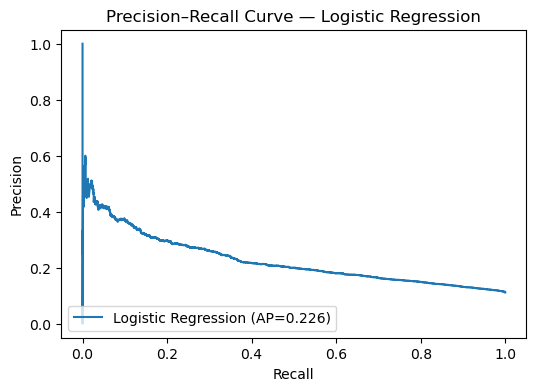


=== Random Forest ===
ROC AUC: 0.6658
PR AUC (Avg Precision): 0.2280
Accuracy: 0.8886
Precision: 0.5556
Recall: 0.0066
F1-score: 0.0131
Confusion Matrix (TN, FP; FN, TP):
 [[18071    12]
 [ 2256    15]]


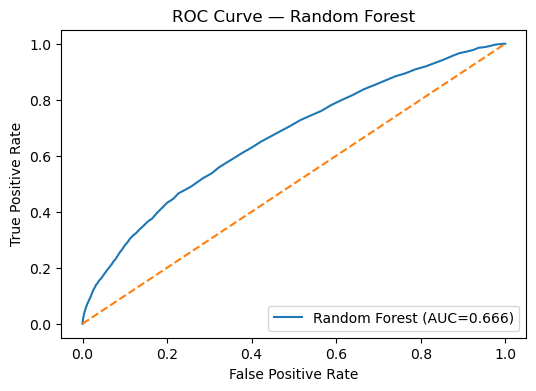

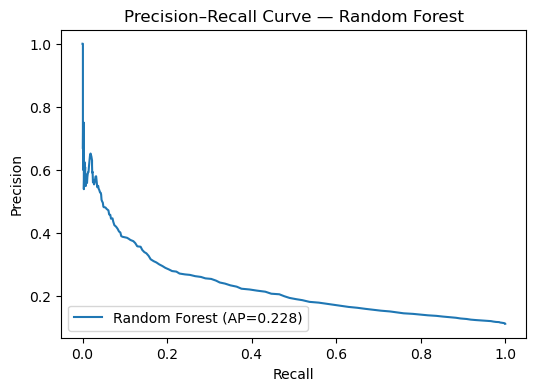

In [10]:

# 9) Evaluation helper
def evaluate_model(name, pipe, X_te, y_te):
    # proba
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        y_proba = pipe.predict_proba(X_te)[:, 1]
    else:
        y_proba = pipe.decision_function(X_te)
    y_pred = (y_proba >= 0.5).astype(int)

    roc_auc = roc_auc_score(y_te, y_proba)
    pr_auc = average_precision_score(y_te, y_proba)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    cm = confusion_matrix(y_te, y_pred)

    print(f"\n=== {name} ===")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"PR AUC (Avg Precision): {pr_auc:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("Confusion Matrix (TN, FP; FN, TP):\n", cm)

    # ROC plot
    fpr, tpr, _ = roc_curve(y_te, y_proba)
    plt.figure()
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {name}")
    plt.legend(loc="lower right")
    plt.show()

    # PR plot
    precision_vals, recall_vals, _ = precision_recall_curve(y_te, y_proba)
    plt.figure()
    plt.plot(recall_vals, precision_vals, label=f"{name} (AP={pr_auc:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve — {name}")
    plt.legend(loc="lower left")
    plt.show()

    return {"name": name, "roc_auc": roc_auc, "pr_auc": pr_auc,
            "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "cm": cm}

res_log = evaluate_model("Logistic Regression", logreg, X_test, y_test)
res_rf  = evaluate_model("Random Forest", rf, X_test, y_test)


In [11]:

# 10) Friendly business summary + simple interpretability
# Get feature names after preprocessing for logistic regression
ohe = logreg.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_features = ohe.get_feature_names_out([c for c in X.columns if c in categorical_cols])
feature_names = np.concatenate([
    [c for c in X.columns if c in numeric_cols],
    cat_features
])

coefs = logreg.named_steps["model"].coef_.ravel()
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()
top10 = coef_df.sort_values("abs_coef", ascending=False).head(10)[["feature","coef"]]

tn, fp, fn, tp = res_rf["cm"].ravel()  # using the RF confusion matrix here

print("==== Business-Friendly Summary ====")
print(f"- We predicted risk of 30-day readmission using two models.")
print(f"- Logistic Regression ROC AUC: {res_log['roc_auc']:.3f}; Random Forest ROC AUC: {res_rf['roc_auc']:.3f}.")
print(f"- Precision: {res_rf['precision']:.3f}, Recall: {res_rf['recall']:.3f}, F1: {res_rf['f1']:.3f} (Random Forest).")
print(f"- Confusion Matrix (RF): TN={tn}, FP={fp}, FN={fn}, TP={tp}.")
print("\nHow to use this:")
print("- Patients with higher predicted risk should receive follow-up calls, earlier appointments, or care management.")
print("- Use the coefficients (LogReg) for interpretability to understand drivers of readmission risk.")
print("- Tune decision threshold depending on whether you want to prioritize recall (catch more at-risk patients) or precision.")

print("\nTop 10 features by magnitude (Logistic Regression):")
display(top10)


==== Business-Friendly Summary ====
- We predicted risk of 30-day readmission using two models.
- Logistic Regression ROC AUC: 0.681; Random Forest ROC AUC: 0.666.
- Precision: 0.556, Recall: 0.007, F1: 0.013 (Random Forest).
- Confusion Matrix (RF): TN=18071, FP=12, FN=2256, TP=15.

How to use this:
- Patients with higher predicted risk should receive follow-up calls, earlier appointments, or care management.
- Use the coefficients (LogReg) for interpretability to understand drivers of readmission risk.
- Tune decision threshold depending on whether you want to prioritize recall (catch more at-risk patients) or precision.

Top 10 features by magnitude (Logistic Regression):


,feature,coef
45,discharge_disposition_id_11,-4.286125
49,discharge_disposition_id_15,1.659131
60,discharge_disposition_id_28,1.448439
47,discharge_disposition_id_13,-1.184265
55,discharge_disposition_id_22,1.101180
90,medical_specialty_Hematology,0.955411
43,discharge_disposition_id_9,0.916826
39,discharge_disposition_id_5,0.853265
113,medical_specialty_Pediatrics-Endocrinology,-0.841807
106,medical_specialty_Otolaryngology,-0.814387
